In [1]:
import scanpy as sc
import anndata as ad
from scipy import stats
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.stats.multitest import multipletests
from collections import defaultdict
import pickle
from tqdm.notebook import tqdm

## ICePop

In [2]:
dfs = []
files = Path('../results/icepop_null_mc-75').rglob('metacell*.csv')
files = [str(file) for file in files]
for file in tqdm(files, total=len(files)):
    df = pd.read_csv(file, header=0, index_col=0, usecols=["metacell", "p"])
    dfs.append(df)
mc_res = pd.concat(dfs, axis=1)
mc_res = np.asarray(mc_res, np.float32).T

  0%|          | 0/10000 [00:00<?, ?it/s]

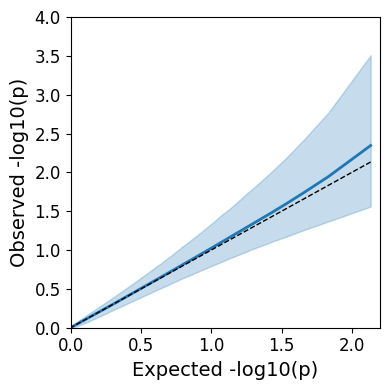

In [3]:
# mc calibration
M = mc_res.shape[1]

# sort each row to form empirical quantiles
sorted_ppp = np.sort(mc_res, axis=1)
obs = -np.log10(sorted_ppp)                          # observed curves
exp = -np.log10( (np.arange(1, M+1) / (M+1)) )       # uniform reference

# summarize
mean_curve = obs.mean(axis=0)
lo = np.percentile(obs, 5, axis=0)
hi = np.percentile(obs, 95,axis=0)

# plot
plt.figure(figsize=(4,4))
plt.plot(exp, mean_curve, color="#1f77b4", lw=2)
plt.fill_between(exp, lo, hi, color="#1f77b4", alpha=0.25)
plt.plot(exp, exp, "k--", lw=1)
plt.xlabel("Expected -log10(p)", fontsize=14)
plt.ylabel("Observed -log10(p)", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title("")
plt.xlim(0.0, 2.2)
plt.ylim(0.0, 4.0)
plt.tight_layout()
plt.savefig('../paper/supp/mc_null.pdf')

In [4]:
dfs = []
files = Path('../results/icepop_null_mc-75').rglob('celltype*.csv')
files = [str(file) for file in files]
for file in tqdm(files, total=len(files)):
    df = pd.read_csv(file, header=0, index_col=0, usecols=["cell_type", "p"])
    dfs.append(df)
icepop_res = pd.concat(dfs, axis=1)
icepop_res = np.asarray(icepop_res, np.float32).T

  0%|          | 0/10000 [00:00<?, ?it/s]

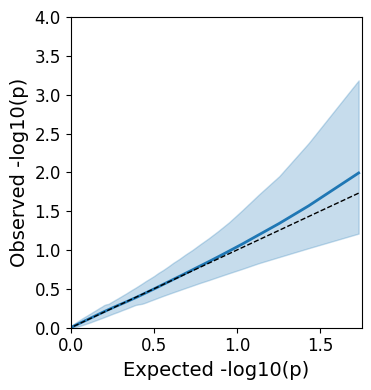

In [5]:
M = icepop_res.shape[1]

# sort each row to form empirical quantiles
sorted_ppp = np.sort(icepop_res, axis=1)
obs = -np.log10(sorted_ppp)                          # observed curves
exp = -np.log10( (np.arange(1, M+1) / (M+1)) )       # uniform reference

# summarize
mean_curve = obs.mean(axis=0)
lo = np.percentile(obs, 5, axis=0)
hi = np.percentile(obs, 95,axis=0)

# plot
plt.figure(figsize=(4,4))
plt.plot(exp, mean_curve, color="#1f77b4", lw=2)
plt.fill_between(exp, lo, hi, color="#1f77b4", alpha=0.25)
plt.plot(exp, exp, "k--", lw=1)
plt.xlabel("Expected -log10(p)", fontsize=14)
plt.ylabel("Observed -log10(p)", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title("")
plt.xlim(0.0, 1.75)
plt.ylim(0.0, 4.0)
plt.tight_layout()
plt.savefig('../paper/main/icepop_null.pdf')

## Seismic

In [6]:
dfs = []
files = Path('../results/seismic_null/').rglob('*.tsv')
files = [str(file) for file in files]
for file in tqdm(files, total=len(files)):
    df = pd.read_csv(file, header=0, index_col=0, sep='\t', usecols=["cell_type", "pvalue"])
    dfs.append(df)
seismic_res = pd.concat(dfs, axis=1)
seismic_res = np.asarray(seismic_res, np.float32).T

  0%|          | 0/10000 [00:00<?, ?it/s]

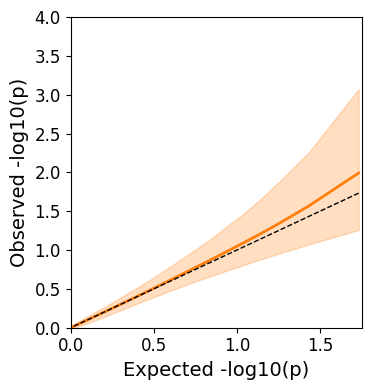

In [7]:
M = seismic_res.shape[1]

# sort each row to form empirical quantiles
sorted_ppp = np.sort(seismic_res, axis=1)
obs = -np.log10(sorted_ppp)                          # observed curves
exp = -np.log10( (np.arange(1, M+1) / (M+1)) )       # uniform reference

# summarize
mean_curve = obs.mean(axis=0)
lo = np.percentile(obs, 5, axis=0)
hi = np.percentile(obs,95,axis=0)

# plot
plt.figure(figsize=(4,4))
plt.plot(exp, mean_curve, color="#ff7f0e", lw=2)
plt.fill_between(exp, lo, hi, color="#ff7f0e", alpha=0.25)
plt.plot(exp, exp, "k--", lw=1)
plt.xlabel("Expected -log10(p)", fontsize=14)
plt.ylabel("Observed -log10(p)", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title("")
plt.xlim(0.0, 1.75)
plt.ylim(0.0, 4.0)
plt.tight_layout()
plt.savefig('../paper/main/seismic_null.pdf')

## scDRS

In [8]:
scdrs_res = []
files = Path('../results/scdrs_null_downstream').glob('*.cell_type')
files = [str(file) for file in files]
for file in tqdm(files, total=len(files)):
    df = pd.read_csv(file, header=0, index_col=0, sep='\t', usecols=["group", "assoc_mcp"])
    dfs.append(df)
scdrs_res = pd.concat(dfs, axis=1)
scdrs_res = np.asarray(scdrs_res, np.float32).T

  0%|          | 0/10000 [00:00<?, ?it/s]

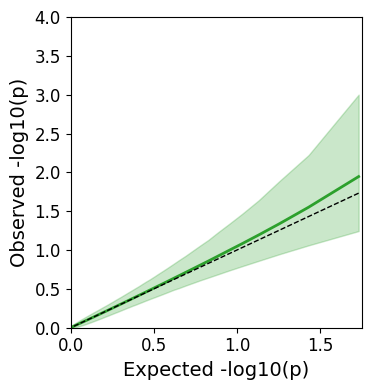

In [9]:
M = scdrs_res.shape[1]

# sort each row to form empirical quantiles
sorted_ppp = np.sort(scdrs_res, axis=1)
obs = -np.log10(sorted_ppp)                          # observed curves
exp = -np.log10( (np.arange(1, M+1) / (M+1)) )       # uniform reference

# summarize
mean_curve = obs.mean(axis=0)
lo = np.percentile(obs, 5, axis=0)
hi = np.percentile(obs,95,axis=0)

# plot
plt.figure(figsize=(4,4))
plt.plot(exp, mean_curve, color="#2ca02c", lw=2)
plt.fill_between(exp, lo, hi, color="#2ca02c", alpha=0.25)
plt.plot(exp, exp, "k--", lw=1)
plt.xlabel("Expected -log10(p)", fontsize=14)
plt.ylabel("Observed -log10(p)", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title("")
plt.xlim(0.0, 1.75)
plt.ylim(0.0, 4.0)
plt.tight_layout()
plt.savefig('../paper/main/scdrs_null.pdf')